In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

print("Performance Analytics Notebook Ready")

Performance Analytics Notebook Ready


In [2]:
funds = pd.read_csv("../data/processed/fund_master_clean.csv")

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

benchmark = pd.read_csv("../data/processed/benchmark_indices_clean.csv")

print(nav.shape)
print(performance.shape)

(46000, 3)
(40, 19)


In [3]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

print("Dates converted")

Dates converted


In [4]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [5]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [6]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund].sort_values("date")

    try:
        nav_end = df["nav"].iloc[-1]

        # 1 Year
        nav_1yr = df.iloc[-252]["nav"]
        cagr_1yr = (nav_end / nav_1yr) - 1

        # 3 Year
        nav_3yr = df.iloc[-756]["nav"]
        cagr_3yr = (nav_end / nav_3yr) ** (1/3) - 1

        # 5 Year
        nav_5yr = df.iloc[-1260]["nav"]
        cagr_5yr = (nav_end / nav_5yr) ** (1/5) - 1

        cagr_results.append([
            fund,
            cagr_1yr,
            cagr_3yr,
            cagr_5yr
        ])

    except:
        pass

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
)

cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr


In [7]:
RF = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    returns = (
        nav[nav["amfi_code"] == fund]
        ["daily_return"]
        .dropna()
    )

    annual_return = returns.mean() * 252

    annual_vol = returns.std() * np.sqrt(252)

    sharpe = (
        (annual_return - RF)
        / annual_vol
    )

    sharpe_results.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [8]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    returns = (
        nav[nav["amfi_code"] == fund]
        ["daily_return"]
        .dropna()
    )

    downside = returns[returns < 0]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        returns.mean()
        * 252
    )

    sortino = (
        (annual_return - RF)
        / downside_std
    )

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [9]:
metrics = (
    cagr_df
    .merge(sharpe_df,
           on="amfi_code")
    .merge(sortino_df,
           on="amfi_code")
)

metrics.to_csv(
    "../reports/fund_metrics.csv",
    index=False
)

metrics.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,sortino_ratio


In [10]:
# Nifty 100

nifty = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty = nifty.sort_values("date")

nifty["benchmark_return"] = (
    nifty["close_value"]
    .pct_change()
)

alpha_beta_results = []

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_df,
        nifty[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 100:

        slope, intercept, r, p, stderr = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = slope

        alpha = intercept * 252

        alpha_beta_results.append([
            fund,
            alpha,
            beta
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [11]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [12]:
mdd_results = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    running_max = df["nav"].cummax()

    drawdown = (
        df["nav"] / running_max
    ) - 1

    max_dd = drawdown.min()

    mdd_results.append([
        fund,
        max_dd
    ])

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

mdd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [13]:
scorecard = (
    metrics
    .merge(alpha_beta_df,
           on="amfi_code")
    .merge(mdd_df,
           on="amfi_code")
)

scorecard["return_rank"] = (
    scorecard["cagr_3yr"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["dd_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

scorecard["fund_score"] = (
      scorecard["return_rank"] * 30
    + scorecard["sharpe_rank"] * 25
    + scorecard["alpha_rank"] * 20
    + scorecard["dd_rank"] * 10
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,sortino_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,dd_rank,fund_score


In [14]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [15]:
import os
os.listdir("../reports")

['alpha_beta.csv',
 'aum_growth.png',
 'category_heatmap.png',
 'folio_growth.html',
 'fund_metrics.csv',
 'fund_scorecard.csv',
 'gender_distribution.html',
 'investor_age_distribution.html',
 'nav_correlation_heatmap.png',
 'nav_trend_analysis.html',
 'sector_allocation.html',
 'sip_amount_by_age.png',
 'sip_trend.html',
 'state_wise_sip.png',
 't30_b30_distribution.html']

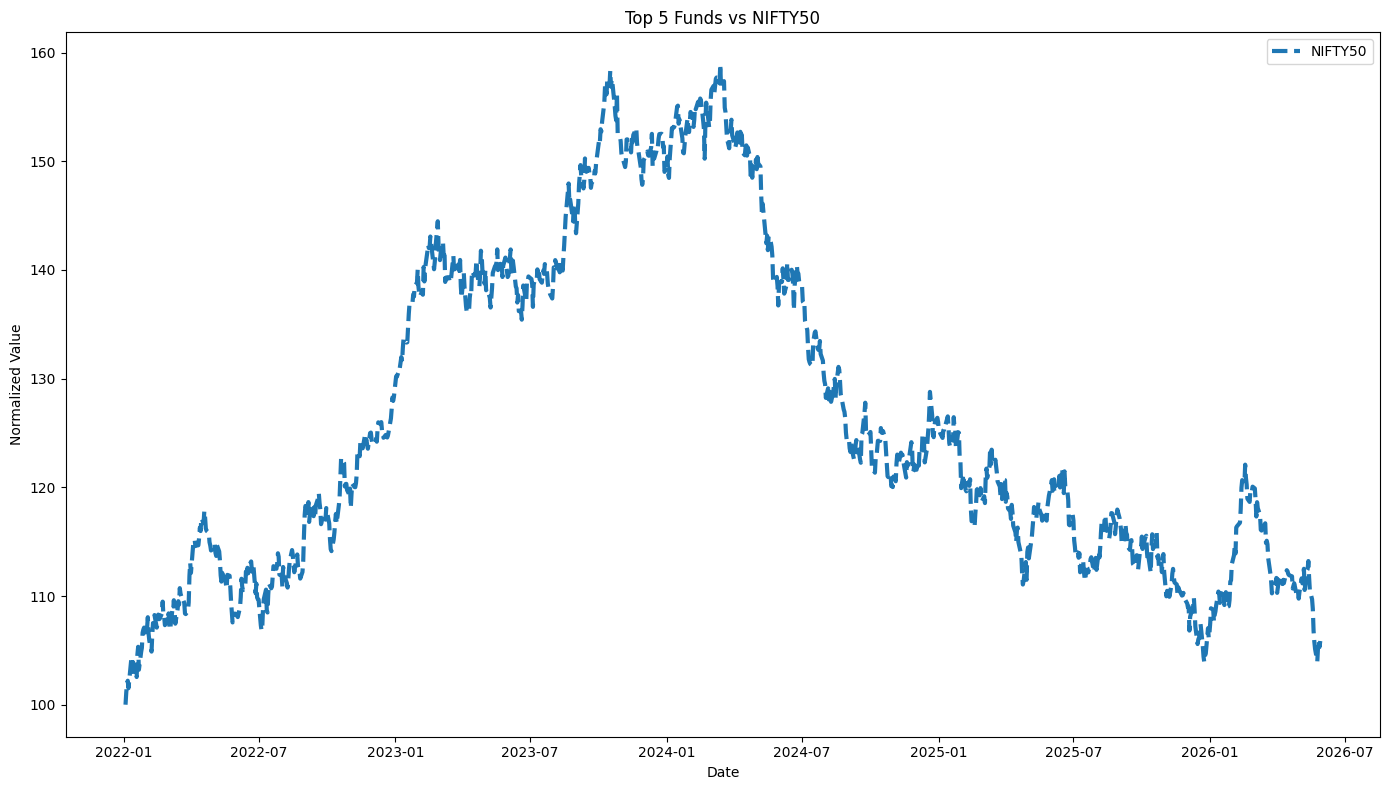

In [16]:
# Top 5 funds by score

top5 = scorecard.head(5)["amfi_code"]

top_nav = nav[
    nav["amfi_code"].isin(top5)
]

top_nav = top_nav.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Normalize NAV
top_nav["normalized_nav"] = (
    top_nav.groupby("scheme_name")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

# NIFTY 50
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50 = nifty50.sort_values("date")

nifty50["normalized"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
    * 100
)

plt.figure(figsize=(14,8))

for scheme in top_nav["scheme_name"].unique():

    df = top_nav[
        top_nav["scheme_name"] == scheme
    ]

    plt.plot(
        df["date"],
        df["normalized_nav"],
        label=scheme
    )

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    linestyle="--",
    label="NIFTY50"
)

plt.title(
    "Top 5 Funds vs NIFTY50"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value")

plt.legend()

plt.tight_layout()

plt.show()

In [17]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

print("Benchmark comparison chart saved")

Benchmark comparison chart saved


<Figure size 640x480 with 0 Axes>

In [18]:
import os

os.listdir("../reports")

['alpha_beta.csv',
 'aum_growth.png',
 'benchmark_comparison.png',
 'category_heatmap.png',
 'folio_growth.html',
 'fund_metrics.csv',
 'fund_scorecard.csv',
 'gender_distribution.html',
 'investor_age_distribution.html',
 'nav_correlation_heatmap.png',
 'nav_trend_analysis.html',
 'sector_allocation.html',
 'sip_amount_by_age.png',
 'sip_trend.html',
 'state_wise_sip.png',
 't30_b30_distribution.html']